# A/B Testing Analysis: Evaluasi Efektivitas Promo terhadap Penjualan

# Latar Belakang
Salah satu strategi yang sering digunakan dalam bisnis retail adalah pemberian promo untuk meningkatkan penjualan produk. Namun, tidak semua promo selalu memberikan dampak yang signifikan terhadap peningkatan penjualan.

Oleh karena itu, diperlukan analisis berbasis data untuk mengetahui apakah transaksi yang mendapatkan promo benar-benar menghasilkan penjualan yang lebih tinggi dibandingkan transaksi tanpa promo.


# Menentukan Pertanyaan Bisnis
1. Apakah transaksi yang menggunakan promo menghasilkan jumlah penjualan yang lebih tinggi dibandingkan transaksi tanpa promo?

2. Seberapa besar pengaruh promo terhadap peningkatan jumlah produk yang dibeli pelanggan?

3. Apakah perbedaan penjualan antara transaksi promo dan non promo terjadi secara signifikan berdasarkan pengujian statistik?

# Tujuan Analisis
Menganalisis pengaruh promo terhadap jumlah penjualan produk menggunakan metode A/B Testing.

# Kelompok Eksperimen
Group A (Control):
- Transaksi tanpa promo

Group B (Treatment):
- Transaksi dengan promo


# Metric
Sales (jumlah produk yang terjual)

# Import Library Yang Digunakan

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import normaltest
from scipy.stats import ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("../data/wrangled_data.csv")

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2021-01-01,store_1,item_1,36,21.3,0,4,1
1,2021-01-02,store_1,item_1,36,21.3,0,5,1
2,2021-01-03,store_1,item_1,35,21.3,0,6,1
3,2021-01-04,store_1,item_1,41,21.3,0,0,1
4,2021-01-05,store_1,item_1,53,21.3,0,1,1


## Data Overview

In [3]:
# Struktur Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      54750 non-null  object 
 1   store_id  54750 non-null  object 
 2   item_id   54750 non-null  object 
 3   sales     54750 non-null  int64  
 4   price     54750 non-null  float64
 5   promo     54750 non-null  int64  
 6   weekday   54750 non-null  int64  
 7   month     54750 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [4]:
# Statistik Deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


In [5]:
# Distribusi Promo
df['promo'].value_counts()

promo
0    49317
1     5433
Name: count, dtype: int64

### Insight

Dataset terdiri dari 54.750 transaksi penjualan dengan 8 variabel dan seluruh data telah lengkap tanpa missing values, sehingga siap digunakan untuk analisis. Rata-rata penjualan tercatat sebesar 29,88 produk per transaksi dengan median 28 produk, yang menunjukkan bahwa sebagian besar pelanggan membeli sekitar 28–30 produk dalam satu kali transaksi. Harga produk berada pada rentang \$12,20 hingga \$99,99 dengan rata-rata \$56,08.

Selain itu, hanya 5.433 transaksi (9,92%) yang menggunakan promo, sedangkan 49.317 transaksi (90,08%) tidak menggunakan promo. Kondisi ini menunjukkan bahwa promo diterapkan pada sebagian kecil transaksi sehingga menarik untuk dianalisis lebih lanjut apakah promo memberikan pengaruh terhadap peningkatan penjualan.

# Exploratory Data Analysis

## Visualisasi Boxplot

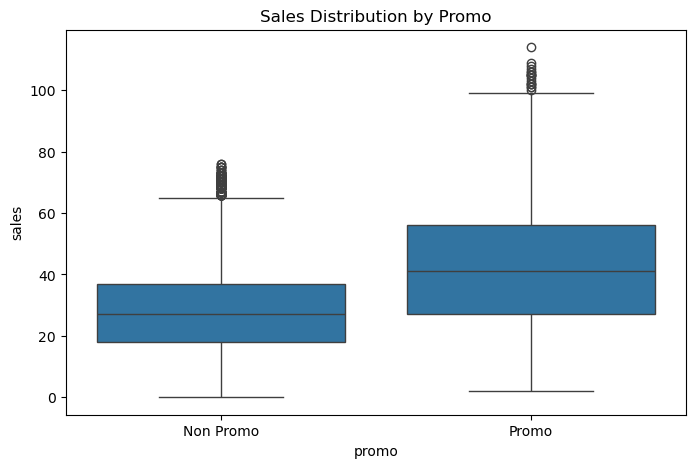

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='promo',
    y='sales'
)

plt.xticks([0,1], ['Non Promo','Promo'])

plt.title('Sales Distribution by Promo')

plt.show()

## Insight

Transaksi yang menggunakan promo cenderung memiliki penjualan lebih tinggi dibandingkan transaksi tanpa promo, terlihat dari median dan rentang penjualannya yang lebih besar. Selain itu, transaksi promo juga menghasilkan nilai penjualan maksimum yang lebih tinggi. Hal ini mengindikasikan bahwa promo berpotensi meningkatkan jumlah produk yang dibeli pelanggan dan akan diuji lebih lanjut melalui A/B Testing.

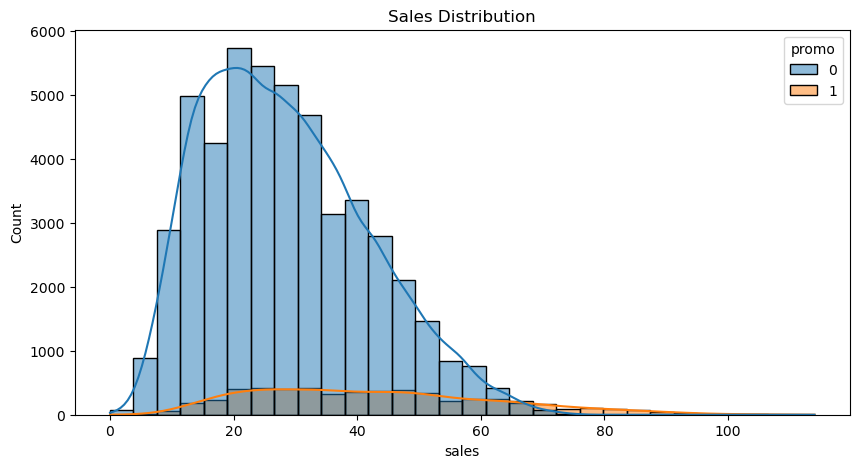

In [7]:
# Visualisasi Histogram
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='sales',
    hue='promo',
    kde=True,
    bins=30
)

plt.title('Sales Distribution')

plt.show()

## Insight

Sebagian besar transaksi, baik promo maupun non promo, berada pada kisaran 20–40 produk per transaksi. Namun, distribusi transaksi promo cenderung berada pada tingkat penjualan yang lebih tinggi dan memiliki nilai maksimum yang lebih besar dibandingkan non promo. Hal ini menunjukkan adanya indikasi bahwa promo dapat mendorong pelanggan membeli lebih banyak produk.

# Uji Normalitas

In [12]:
stat, p = normaltest(df['sales'])

print("Statistic:", stat)
print("P-value:", p)

Statistic: 5409.705581636568
P-value: 0.0


### Insight

Hasil uji normalitas menunjukkan bahwa p-value lebih kecil dari 0,05 sehingga H0 ditolak. Dengan demikian, data penjualan tidak berdistribusi normal.

Namun, penelitian ini menggunakan 54.750 observasi yang merupakan jumlah sampel sangat besar. Berdasarkan Central Limit Theorem (CLT), distribusi rata-rata sampel akan mendekati distribusi normal ketika ukuran sampel besar. Oleh karena itu, Independent Two Sample T-Test tetap dapat digunakan untuk membandingkan rata-rata penjualan antara kelompok promo dan non promo.

# Membentuk Kelompok Data

In [8]:
promo_sales = df[df['promo'] == 1]['sales']

nonpromo_sales = df[df['promo'] == 0]['sales']

# Menjalankan A/B Testing Menggunakan Uji t

Pemilihan uji t dilakukan karena variabel yang dianalisis adalah sales yang berupa data numerik kontinu, sedangkan variabel promo digunakan sebagai pembeda kelompok (promo dan non promo). Tujuan pengujian ini adalah untuk mengetahui apakah perbedaan rata-rata penjualan yang terlihat pada kedua kelompok terjadi secara signifikan atau hanya disebabkan oleh variasi data secara acak.

Hipotesis yang digunakan dalam pengujian ini adalah sebagai berikut:

- H0: Tidak terdapat perbedaan rata-rata penjualan antara transaksi promo dan non promo.

- H1: Terdapat perbedaan rata-rata penjualan antara transaksi promo dan non promo.

Pengujian dilakukan dengan tingkat signifikansi (α) sebesar 0,05. Jika nilai p-value lebih kecil dari 0,05, maka H0 ditolak dan dapat disimpulkan bahwa terdapat perbedaan penjualan yang signifikan antara kedua kelompok.

In [9]:
t_stat, p_value = ttest_ind(
    promo_sales,
    nonpromo_sales,
    equal_var=False
)

print("T Statistic :", t_stat)
print("P Value :", p_value)

T Statistic : 52.864978306000026
P Value : 0.0


In [10]:
alpha = 0.05

if p_value < 0.05:

    print(
        "Terdapat perbedaan yang signifikan antara transaksi promo "
        "dan non promo."
    )

else:

    print(
        "Belum terdapat bukti yang cukup bahwa promo "
        "mempengaruhi penjualan."
    )

Terdapat perbedaan yang signifikan antara transaksi promo dan non promo.


In [11]:
promo_mean = promo_sales.mean()

nonpromo_mean = nonpromo_sales.mean()

increase = (
    (promo_mean - nonpromo_mean)
    / nonpromo_mean
) * 100

print(f"Promo meningkatkan penjualan sebesar {increase:.2f}%")

Promo meningkatkan penjualan sebesar 50.78%


### Insight
Berdasarkan hasil Independent Two Sample T-Test diperoleh:
- T-Statistic = 52.86
- P-Value < 0.001
Karena nilai p-value lebih kecil dari tingkat signifikansi 0.05, maka hipotesis nol (H0) ditolak.

Dengan demikian, terdapat perbedaan yang signifikan antara transaksi yang menggunakan promo dan transaksi tanpa promo.

# Business Insight

### 1. Apakah transaksi yang menggunakan promo menghasilkan jumlah penjualan yang lebih tinggi dibandingkan transaksi tanpa promo?

Ya. Berdasarkan analisis data, transaksi yang menggunakan promo menunjukkan rata-rata penjualan yang lebih tinggi dibandingkan transaksi tanpa promo. Temuan ini juga terlihat pada visualisasi distribusi penjualan dan boxplot, di mana kelompok promo memiliki median penjualan yang lebih tinggi serta rentang penjualan yang lebih besar.

### 2. Seberapa besar pengaruh promo terhadap peningkatan jumlah produk yang dibeli pelanggan?

Hasil perhitungan menunjukkan bahwa transaksi yang menggunakan promo menghasilkan rata-rata penjualan sekitar 50,78% lebih tinggi dibandingkan transaksi tanpa promo. Hal ini mengindikasikan bahwa promo mampu mendorong pelanggan untuk membeli produk dalam jumlah yang lebih banyak dibandingkan kondisi normal.

### 3. Apakah perbedaan penjualan antara transaksi promo dan non promo terjadi secara signifikan berdasarkan pengujian statistik?

Ya. Berdasarkan hasil Independent Two Sample T-Test diperoleh nilai T-Statistic sebesar 52,86 dan P-Value < 0,05. Karena nilai p-value jauh lebih kecil dari tingkat signifikansi 5%, maka hipotesis nol (H0) ditolak. Dengan demikian, terdapat perbedaan penjualan yang signifikan secara statistik antara transaksi promo dan non promo.

## Business Recommendation
Berdasarkan hasil A/B Testing, strategi promo terbukti efektif dalam meningkatkan penjualan.

Rekomendasi yang dapat dilakukan antara lain:

1. Mempertahankan program promo yang telah berjalan.
2. Memperluas promo pada produk dengan performa penjualan tinggi.
3. Menjadwalkan promo pada periode dengan potensi permintaan tinggi.
4. Melakukan evaluasi lebih lanjut terhadap jenis promo yang memberikan dampak terbesar terhadap penjualan.